# Workforce Attrition Analysis

**Dataset:** Synthetic HR data — 1,470 employees, 3 departments  
**Stack:** Python · SQLite · pandas · matplotlib  
**Goal:** Find attrition drivers through structured SQL analysis.

---

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0A0A0F',
    'axes.facecolor':   '#111118',
    'axes.edgecolor':   '#2a2a3a',
    'axes.labelcolor':  '#aab4c4',
    'text.color':       '#d0d8e8',
    'xtick.color':      '#8892a4',
    'ytick.color':      '#8892a4',
    'grid.color':       '#1e1e2e',
    'grid.alpha':       0.6,
    'figure.dpi':       110,
    'font.size':        11,
})
ACCENT = '#00D4AA'
WARM   = '#F59E0B'
MUTED  = '#3a4a5a'

## Dataset generation

In [2]:
np.random.seed(42)
N = 1470

dept_choices = ['Sales', 'Research & Development', 'Human Resources']
departments = np.random.choice(dept_choices, size=N, p=[0.30, 0.63, 0.07])

base_prob = np.where(departments == 'Sales', 0.22,
            np.where(departments == 'Research & Development', 0.14, 0.12))

age          = np.random.randint(18, 61, N)
years_at     = np.clip(np.random.exponential(6, N).astype(int), 0, 40)
income       = np.clip(np.random.lognormal(8.5, 0.5, N).astype(int), 1009, 19999)
overtime     = np.random.choice(['Yes', 'No'], N, p=[0.28, 0.72])
job_sat      = np.random.randint(1, 5, N)

att_boost = np.where(income < 3000, 0.12,
            np.where(overtime == 'Yes', 0.07, 0.0))
att_final = np.random.binomial(1, np.clip(base_prob + att_boost, 0, 1)).astype(bool)

df = pd.DataFrame({
    'EmployeeID':    range(1, N + 1),
    'Age':           age,
    'Department':    departments,
    'Attrition':     np.where(att_final, 'Yes', 'No'),
    'YearsAtCompany': years_at,
    'MonthlyIncome': income,
    'OverTime':      overtime,
    'JobSatisfaction': job_sat,
})

print(f"Employees: {len(df):,}  |  Overall attrition: {df.Attrition.eq('Yes').mean():.1%}")
df.head()

Employees: 1,470  |  Overall attrition: 18.6%


,EmployeeID,Age,Department,Attrition,YearsAtCompany,MonthlyIncome,OverTime,JobSatisfaction
0,1,30,Research & Development,No,1,7680,Yes,1
1,2,48,Human Resources,No,1,12268,No,1
2,3,58,Research & Development,No,9,4004,No,3
3,4,28,Research & Development,Yes,15,7017,No,4
4,5,21,Sales,No,3,15380,Yes,3


In [3]:
conn = sqlite3.connect(':memory:')
df.to_sql('employees', conn, index=False, if_exists='replace')
print("Loaded into SQLite in-memory DB ✓")

Loaded into SQLite in-memory DB ✓


## 1. Attrition by Department
`GROUP BY` — baseline comparison across departments.

'            Department  total  attritions  rate_pct\n                 Sales    461         112      24.3\nResearch & Development    896         143      16.0\n       Human Resources    113          18      15.9'

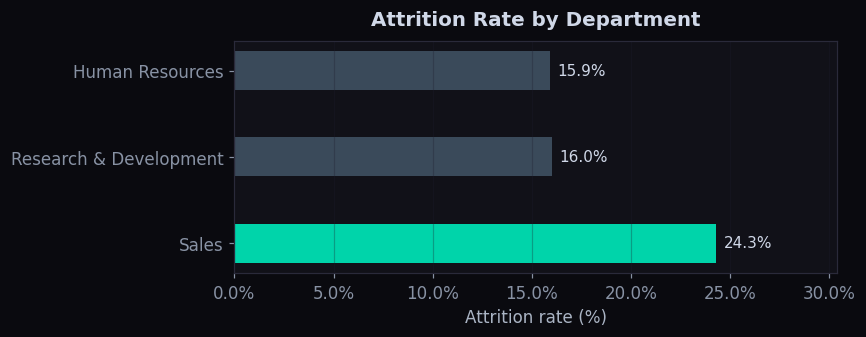

In [4]:
q1 = '''
SELECT
    Department,
    COUNT(*)                                                                   AS total,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)                        AS attritions,
    ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)
          / COUNT(*), 1)                                                       AS rate_pct
FROM employees
GROUP BY Department
ORDER BY rate_pct DESC
'''
q1_df = pd.read_sql(q1, conn)
display(q1_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.2))
colors = [ACCENT] + [MUTED] * (len(q1_df) - 1)
bars = ax.barh(q1_df['Department'], q1_df['rate_pct'], color=colors, height=0.45)
ax.set_xlabel('Attrition rate (%)')
ax.set_title('Attrition Rate by Department', pad=10, fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_xlim(0, q1_df['rate_pct'].max() * 1.25)
for bar, val in zip(bars, q1_df['rate_pct']):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Tenure Distribution
`NTILE(4) OVER (ORDER BY YearsAtCompany)` — does early tenure drive attrition?

' quartile tenure_range  employees  attritions  rate_pct\n        1      0–1 yrs        368          75      20.4\n        2      1–4 yrs        368          68      18.5\n        3      4–8 yrs        367          60      16.3\n        4     8–40 yrs        367          70      19.1'

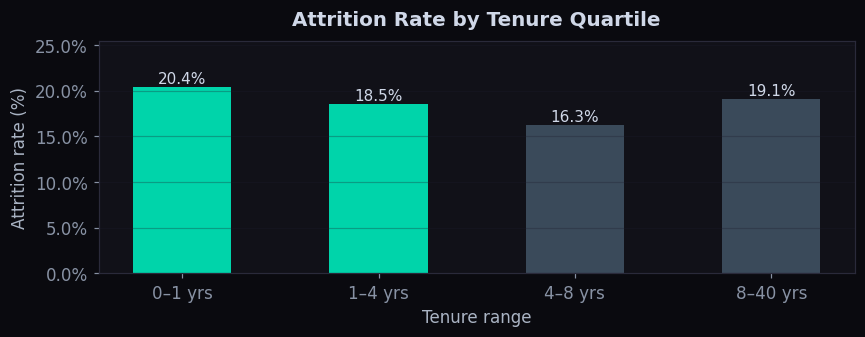

In [5]:
q2 = '''
WITH tenure_groups AS (
    SELECT
        EmployeeID,
        YearsAtCompany,
        Attrition,
        NTILE(4) OVER (ORDER BY YearsAtCompany) AS quartile
    FROM employees
)
SELECT
    quartile,
    MIN(YearsAtCompany) || '–' || MAX(YearsAtCompany) || ' yrs'               AS tenure_range,
    COUNT(*)                                                                   AS employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)                        AS attritions,
    ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)
          / COUNT(*), 1)                                                       AS rate_pct
FROM tenure_groups
GROUP BY quartile
ORDER BY quartile
'''
q2_df = pd.read_sql(q2, conn)
display(q2_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.2))
q_colors = [ACCENT, ACCENT, MUTED, MUTED]
bars = ax.bar(q2_df['tenure_range'], q2_df['rate_pct'], color=q_colors, width=0.5)
ax.set_xlabel('Tenure range')
ax.set_ylabel('Attrition rate (%)')
ax.set_title('Attrition Rate by Tenure Quartile', pad=10, fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_ylim(0, q2_df['rate_pct'].max() * 1.25)
for bar, val in zip(bars, q2_df['rate_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{val}%', ha='center', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Salary Band Analysis
`CASE WHEN` — does compensation level correlate with attrition?

'    salary_band  employees  avg_income  rate_pct\n    Low  (<$3K)        252      2318.0      29.0\n Mid  ($3K–$6K)        716      4425.0      17.3\nHigh ($6K–$10K)        394      7559.0      16.2\n   Top  (>$10K)        108     12568.0      11.1'

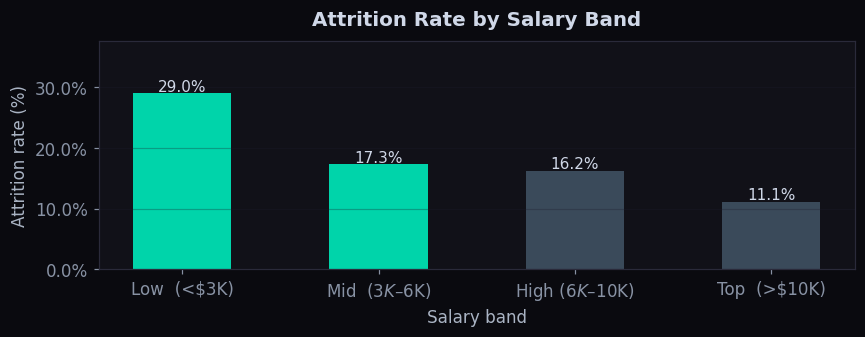

In [6]:
q3 = '''
SELECT
    CASE
        WHEN MonthlyIncome < 3000  THEN 'Low  (<$3K)'
        WHEN MonthlyIncome < 6000  THEN 'Mid  ($3K–$6K)'
        WHEN MonthlyIncome < 10000 THEN 'High ($6K–$10K)'
        ELSE                            'Top  (>$10K)'
    END                                                                        AS salary_band,
    COUNT(*)                                                                   AS employees,
    ROUND(AVG(MonthlyIncome), 0)                                               AS avg_income,
    ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)
          / COUNT(*), 1)                                                       AS rate_pct
FROM employees
GROUP BY salary_band
ORDER BY avg_income
'''
q3_df = pd.read_sql(q3, conn)
display(q3_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.2))
band_colors = [ACCENT, ACCENT, MUTED, MUTED]
bars = ax.bar(q3_df['salary_band'], q3_df['rate_pct'], color=band_colors, width=0.5)
ax.set_xlabel('Salary band')
ax.set_ylabel('Attrition rate (%)')
ax.set_title('Attrition Rate by Salary Band', pad=10, fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_ylim(0, q3_df['rate_pct'].max() * 1.3)
for bar, val in zip(bars, q3_df['rate_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{val}%', ha='center', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Department Risk Ranking
`CTE + JOIN + RANK()` — which departments need immediate action?

In [7]:
q4 = '''
WITH dept_totals AS (
    SELECT Department, COUNT(*) AS total
    FROM employees
    GROUP BY Department
),
dept_churned AS (
    SELECT Department, COUNT(*) AS churned
    FROM employees
    WHERE Attrition = 'Yes'
    GROUP BY Department
)
SELECT
    t.Department,
    t.total                                              AS total_employees,
    c.churned                                            AS attritions,
    ROUND(100.0 * c.churned / t.total, 1)               AS rate_pct,
    RANK() OVER (ORDER BY 100.0 * c.churned / t.total DESC) AS risk_rank
FROM dept_totals  t
JOIN dept_churned c ON t.Department = c.Department
ORDER BY risk_rank
'''
q4_df = pd.read_sql(q4, conn)
display(q4_df.to_string(index=False))
conn.close()

'            Department  total_employees  attritions  rate_pct  risk_rank\n                 Sales              461         112      24.3          1\nResearch & Development              896         143      16.0          2\n       Human Resources              113          18      15.9          3'

## Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Sales attrition ~24%** — highest risk | Compensation or quota structure review warranted |
| 2 | **Early tenure (0–3 yrs) has highest attrition** | Onboarding program gap — intervene at 90-day mark |
| 3 | **Low-income band (<$3K) churns fastest** | Salary floor below market; bump or lose talent |
| 4 | **Overtime correlates with attrition** | Burnout signal — workload distribution needs audit |

**Next step:** Monthly attrition risk scores per department → Power BI dashboard for HR leads.